In [1]:
# Plot example of annual PM2.5

In [2]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure, land_filter, adjust_longitude

In [5]:
# === Path config ===
MDA8_DIR = "/glade/work/awells/air_quality/CESM/pm25/annual_pm25/"

ssp245_file = "PM25_CESM2_SSP245_01_2020-2069.nc"
ssp245_path = os.path.join(MDA8_DIR, ssp245_file)
ssp245 = xr.open_dataarray(ssp245_path)*10**9  # to µg/m3

arise_file = "PM25_CESM2_ARISE_01_2035-2069.nc"
arise_path = os.path.join(MDA8_DIR, arise_file)
arise = xr.open_dataarray(arise_path)*10**9  # to µg/m3

In [6]:
def plot_pm25(da, scenario, SAVE_DIR, land=False):
    # Create figure and layout
    fig = plt.figure(figsize=autosize_figure(1, 1))
    gs = GridSpec(2, 1, height_ratios=[15, 1])

    projection = ccrs.Robinson()
    crs = ccrs.PlateCarree()

    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='50m',
        facecolor='none')

    if land is True:
        da = land_filter(da)

    # Plot map
    ax = fig.add_subplot(gs[0, 0], projection=projection)
    cb = da.plot(
        transform=crs,
        add_colorbar=False,
        cmap='viridis',
        subplot_kws={'projection': projection}
    )
    ax.coastlines(resolution="50m", linewidth=0.75)
    ax.add_feature(country_borders, edgecolor='k', linewidth=0.75)
    plt.title(f"Annual PM2.5 {scenario}\n 2060-2069", fontsize=16)

    # Colorbar
    cax = fig.add_subplot(gs[1, 0])
    col_bar = plt.colorbar(cb, cax=cax, orientation='horizontal')
    col_bar.set_label("PM2.5 (µg/m3)", fontsize=13)

    plt.tight_layout()

    if land is True:
        out_file = f"Annual_PM25_land_{scenario}_2060-2069.png"
    else:
        out_file = f"Annual_PM25_{scenario}_2060-2069.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

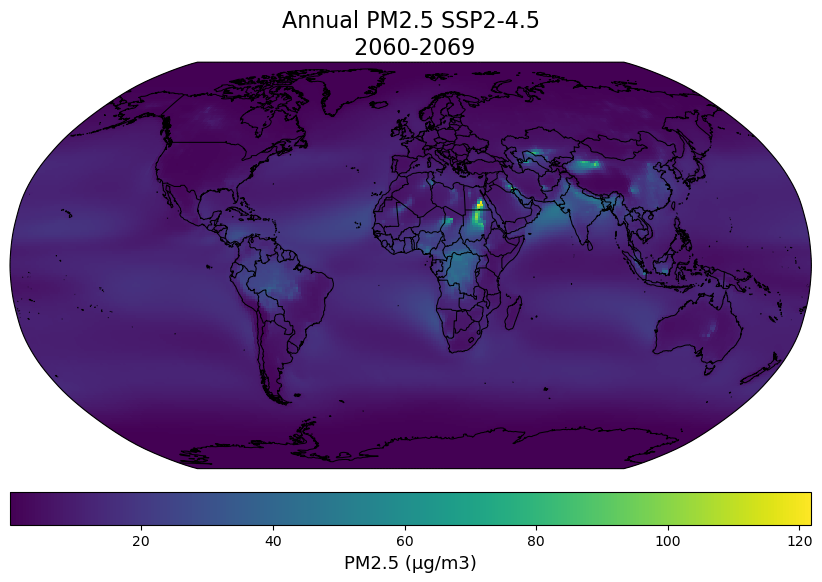

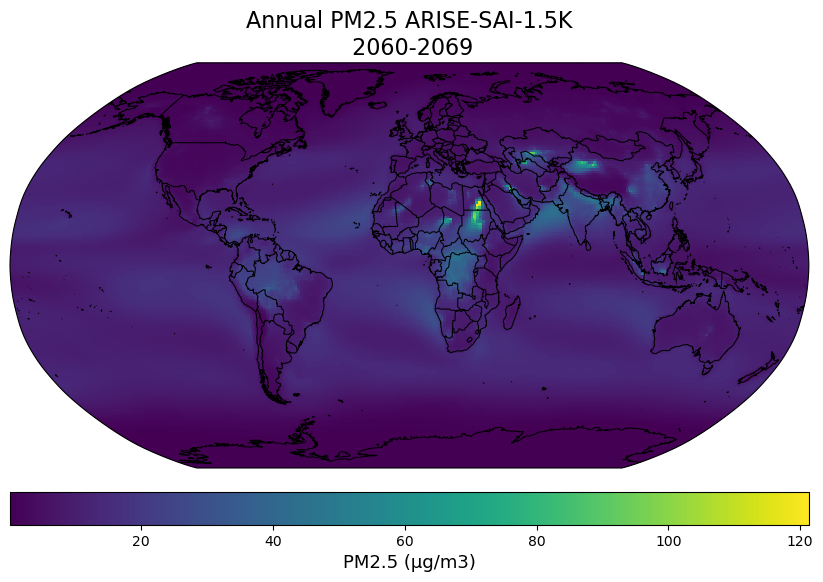

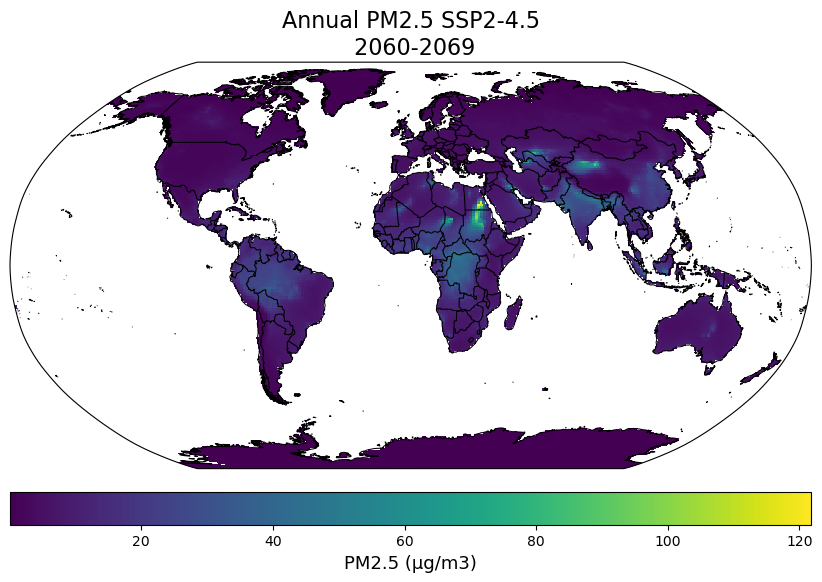

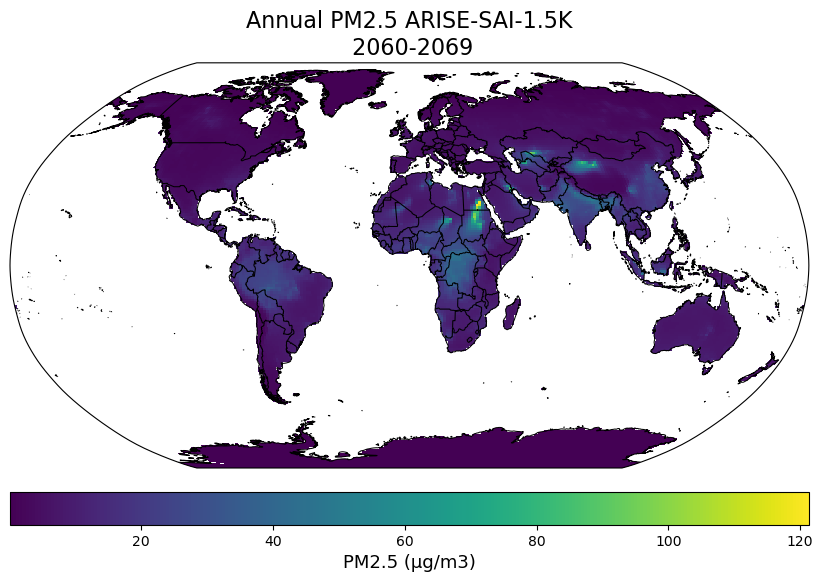

In [8]:
# === Main ===
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/pm25/"

# Select final decade
time = slice("2060", "2069")
ssp245_slice = ssp245.sel(year=time).mean("year")
arise_slice = arise.sel(year=time).mean("year")

ssp245_adj = adjust_longitude(ssp245_slice)
arise_adj = adjust_longitude(arise_slice)

# Plot global
plot_pm25(ssp245_adj, "SSP2-4.5", SAVE_DIR)
plot_pm25(arise_adj, "ARISE-SAI-1.5K", SAVE_DIR)

# Plot land only
plot_pm25(ssp245_adj, "SSP2-4.5", SAVE_DIR, land=True)
plot_pm25(arise_adj, "ARISE-SAI-1.5K", SAVE_DIR, land=True)